# Data-efficiency v2 — Plain Multires, \(n_{\mathrm{train}}=20794\)

Follows **`PROTOCOL_v2.txt` / `PROTOCOL_v2.md`** (plain network only, \(\lambda=0\)).

| Item | Value |
|------|-------|
| Protocol | **v2** |
| Data | Spectrally filtered C1 |
| Model | Multires, \(\lambda=0\) |
| \(n_{\mathrm{train}}\) | **20794** |
| \(n_{\mathrm{val}}\) / \(n_{\mathrm{test}}\) | 200 / 512 (shared seeds) |
| Batch \(B\) | **64** |
| LR | **\(10^{-3}\)** fixed (no LR tuning) |
| Train SNR | U[0, 30] dB |
| Val SNR | discrete **\{−10, 0, 30\}** dB |
| Early stop | `patience_steps=23437`, `max_steps=187500` (\(n>3000\) band; operator-adjustable) |
| Snapshots | every 2 epochs; fixed val sample @ SNR=10 dB |

Artifacts: `checkpoints/v2/n20794_plain/` under this folder.

Run order: setup → Helpers → train → curves → snapshots → SNR sweep → test example → summary.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

from pathlib import Path
import json
import math
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

HERE = Path.cwd()
if (HERE / "setup_src_path.py").exists():
    sys.path.insert(0, str(HERE))
    import setup_src_path  # noqa: F401
    EXP = HERE
elif (HERE / "data efficiency experiment" / "setup_src_path.py").exists():
    EXP = HERE / "data efficiency experiment"
    sys.path.insert(0, str(EXP))
    import setup_src_path  # noqa: F401
else:
    raise RuntimeError("Run from src/ or from data efficiency experiment/")

import data_c_amb_loss_diagnostics as diag
from data_generation import filtered_c1_pulse_config
from dataset_utils import build_filtered_c1_frog_dataloaders
from evaluate_cnn import load_cnn_sweep
from frog_reconstruction_model import extract_pulse_prediction
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    best_similarity_error_ambiguity,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = EXP / "checkpoints" / "v2" / "n20794_plain"
OUT.mkdir(parents=True, exist_ok=True)

PROTOCOL = "v2"
N_TRAIN = 20794
N_VAL = 200
N_TEST = 512
BATCH_SIZE = 64
SEED = 0  # val=seed+1, test=seed+2
LR = 1e-3
EARLY_STOP_MODE = "steps"
TRAIN_SNR = (0.0, 30.0)
VAL_SNR_RANGE = (-10.0, 30.0)  # unused when VAL_SNR_VALUES is set
VAL_SNR_VALUES = [-10.0, 0.0, 30.0]  # PROTOCOL v2 discrete val SNR
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)
SNAPSHOT_EVERY = 2
SNAPSHOT_SNR_DB = 10.0
SNAPSHOT_VAL_INDEX = 0
SNAPSHOT_NOISE_SEED = 12345

STEPS_PER_EPOCH = math.ceil(N_TRAIN / BATCH_SIZE)  # K
# PROTOCOL v2: n_train > 3000 band (adjustable by operator decision)
MAX_STEPS = 187500
PATIENCE_STEPS = 23437
MAX_EPOCHS = max(1, math.ceil(MAX_STEPS / STEPS_PER_EPOCH))

FORCE_RETRAIN = False
FORCE_TEST_SWEEP = False

print("device:", DEVICE)
print("protocol:", PROTOCOL)
print("EXP:", EXP.resolve())
print("OUT:", OUT.resolve())
print("pulse cfg:", filtered_c1_pulse_config(n=64))
print(
    f"n_train={N_TRAIN}  B={BATCH_SIZE}  K={STEPS_PER_EPOCH}  "
    f"LR={LR:g}  max_steps={MAX_STEPS}  patience_steps={PATIENCE_STEPS}  "
    f"max_epochs={MAX_EPOCHS}"
)
print("train SNR: U[0,30]  |  val SNR values:", VAL_SNR_VALUES)
print(f"early_stop: {EARLY_STOP_MODE}")
print(f"FORCE_RETRAIN={FORCE_RETRAIN}  FORCE_TEST_SWEEP={FORCE_TEST_SWEEP}")


device: cuda
protocol: v2
EXP: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment
OUT: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n20794_plain
pulse cfg: FilteredC1PulseConfig(n=64, t_total_fs=70.0, n_spikes=500, central_energy_ev=10000.0, coherence_time_fs=1.0, t_center_std_fs=5.73, delta_energy_ev_range=0.00065, fwhm_ev=0.45, amplitude_min=0.75, amplitude_max=1.0, use_delta_omega=True)
n_train=20794  B=64  K=325  LR=0.001  max_steps=187500  patience_steps=23437  max_epochs=577
train SNR: U[0,30]  |  val SNR values: [-10.0, 0.0, 30.0]
early_stop: steps
FORCE_RETRAIN=False  FORCE_TEST_SWEEP=False


## Helpers


In [2]:
def run_tag() -> str:
    return f"n{N_TRAIN}_plain_lr1e-3_v2"


def load_meta(tag: str) -> dict:
    return json.loads((OUT / f"{tag}_meta.json").read_text(encoding="utf-8"))


def train_plain(tag: str, *, role: str = "plain_official"):
    hist_path = OUT / f"{tag}_history.npz"
    if hist_path.exists() and not FORCE_RETRAIN:
        print(f"skip {role}; using", hist_path)
        return None
    print(
        f"=== {role}: {tag}  lr={LR:g}  lam=0  "
        f"early_stop={EARLY_STOP_MODE}(patience_steps={PATIENCE_STEPS})  "
        f"max_steps={MAX_STEPS}  snap_every={SNAPSHOT_EVERY} ==="
    )
    t0 = time.perf_counter()
    result = diag.train_data_c_amb_diagnostics(
        pulse_loss_mode="raw",
        lam=0.0,
        n_train=N_TRAIN,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=BATCH_SIZE,
        seed=SEED,
        max_epochs=int(MAX_EPOCHS),
        patience=int(PATIENCE_STEPS),
        lr=float(LR),
        train_snr_db_range=TRAIN_SNR,
        val_snr_db_range=VAL_SNR_RANGE,
        val_snr_db_values=VAL_SNR_VALUES,
        device=DEVICE,
        verbose=True,
        ambiguity_backend="legacy",
        trace_loss_ref="clean",
        loader_builder="filtered_c1",
        canonicalize_mode="t0",
        max_steps=int(MAX_STEPS),
        snapshot_every=int(SNAPSHOT_EVERY),
        snapshot_snr_db=SNAPSHOT_SNR_DB,
        snapshot_val_index=SNAPSHOT_VAL_INDEX,
        snapshot_noise_seed=SNAPSHOT_NOISE_SEED,
        early_stop_mode=EARLY_STOP_MODE,
    )
    result_save = {k: v for k, v in result.items() if k != "bundle"}
    result_save["role"] = role
    result_save["protocol"] = PROTOCOL
    diag.save_run_artifacts(result_save, OUT, tag)
    meta = load_meta(tag)
    meta["role"] = role
    meta["protocol"] = PROTOCOL
    meta["val_snr_policy"] = "discrete_{-10,0,30}"
    meta["wall_time_total_sec"] = float(time.perf_counter() - t0)
    (OUT / f"{tag}_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(json.dumps(meta, indent=2))
    return result


def summarize_timings(hist, name):
    keys = [
        "timing_data_prep_sec",
        "timing_loss_data_fwd_sec",
        "timing_loss_reg_fwd_sec",
        "timing_total_backward_sec",
        "timing_optimizer_step_sec",
    ]
    print(f"=== {name}: mean±std over epochs (ms/batch) ===")
    for k in keys:
        if k not in hist:
            continue
        x = np.asarray(hist[k], dtype=float) * 1e3
        print(f"  {k.replace('timing_', ''):22s}  {x.mean():7.3f} ± {x.std():6.3f}")


def plot_pulse_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["train_pulse_l1_raw"], label="raw")
    axes[0].plot(hist["train_pulse_l1_amb"], label="best-amb")
    axes[0].set_title(f"{title_prefix}: train pulse L1")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist["val_pulse_l1_raw"], label="raw")
    axes[1].plot(hist["val_pulse_l1_amb"], label="best-amb")
    axes[1].set_title(f"{title_prefix}: val pulse L1 (SNR∈{{-10,0,30}})")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_trace_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["train_trace_l1"])
    axes[0].set_title(f"{title_prefix}: train TRACE L1")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist["val_trace_l1"])
    axes[1].set_title(f"{title_prefix}: val TRACE L1 (SNR∈{{-10,0,30}})")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_grad_norms(hist, title_prefix, lam=0.0):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(hist["grad_norm_data"], label=r"$||\nabla L_{\mathrm{data}}||$")
    ax.semilogy(
        hist["grad_norm_reg"],
        label=r"$||\nabla L_{\mathrm{reg}}||$ (NOT in loss)",
        alpha=0.7,
    )
    if "grad_norm_total" in hist and len(hist["grad_norm_total"]):
        ax.semilogy(hist["grad_norm_total"], label=r"$||\nabla L_{\mathrm{total}}||$")
    ax.set_xlabel("epoch")
    ax.set_ylabel("grad norm")
    ax.set_title(title_prefix)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Train plain (λ=0, LR=1e−3, PROTOCOL v2)


In [3]:
TAG = run_tag()
train_plain(TAG, role="plain_official")
hist = diag.load_history(OUT / f"{TAG}_history.npz")
meta = load_meta(TAG)
print(json.dumps(meta, indent=2))
print(
    f"best_step={meta.get('best_step')}  best_epoch={meta.get('best_epoch')}  "
    f"global_step={meta.get('global_step')}  max_steps={meta.get('max_steps')}  "
    f"stopped_epoch={meta.get('stopped_epoch')}"
)


skip plain_official; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n20794_plain\n20794_plain_lr1e-3_v2_history.npz
{
  "best_epoch": 20,
  "best_score": 1.5830993518233298,
  "stopped_epoch": 93,
  "lam": 0.0,
  "trace_scale": 7.931127560317375,
  "pulse_loss_mode": "raw",
  "ambiguity_backend": "legacy",
  "trace_loss_ref": "clean",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "train_snr_db_values": null,
  "val_snr_db_range": [
    -10.0,
    30.0
  ],
  "val_snr_db_values": [
    -10.0,
    0.0,
    30.0
  ],
  "n_train": 20794,
  "n_val": 200,
  "seed": 0,
  "loader_builder": "filtered_c1",
  "canonicalize_mode": "t0",
  "lr": 0.001,
  "batch_size": 64,
  "max_steps": 187500,
  "global_step": 30225,
  "best_step": 6500,
  "early_stop_mode": "steps",
  "early_stop_frac": 0.9,
  "patience": 23437,
  "wall_time_data_sec": 178.34238869999535,
  "wall_time_train_sec": 7824.5826544999145,
  "extension_steps": null,

## Training curves (pulse / TRACE / gradients / timings)


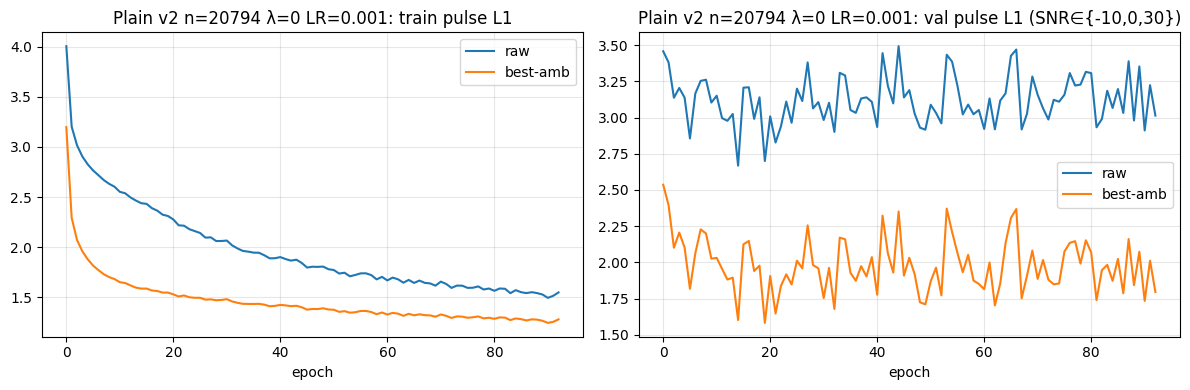

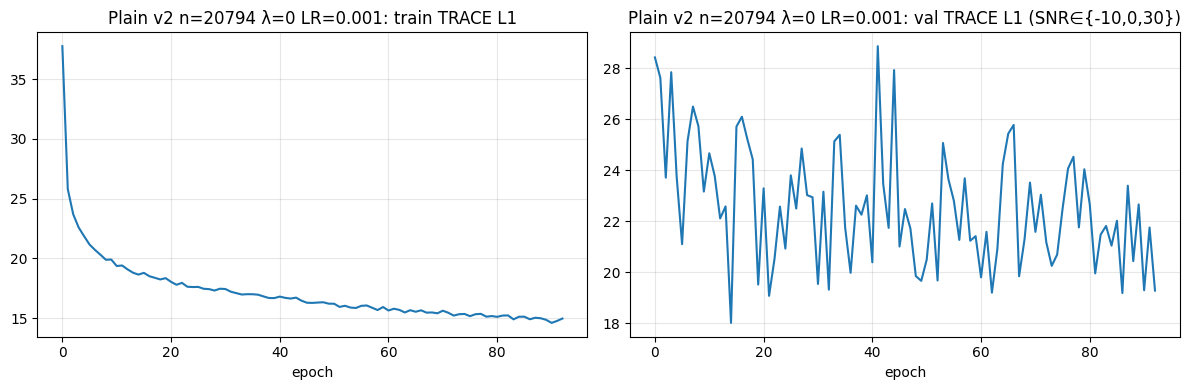

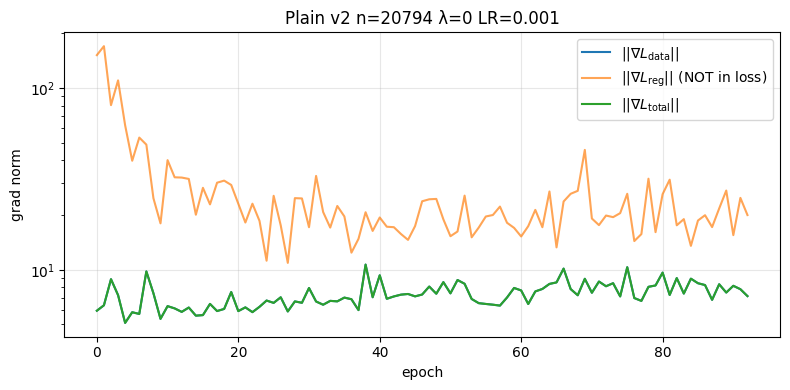

=== Plain v2 n=20794: mean±std over epochs (ms/batch) ===
  data_prep_sec             0.627 ±  0.055
  loss_data_fwd_sec        26.228 ±  0.111
  loss_reg_fwd_sec         10.344 ±  0.782
  total_backward_sec       48.612 ±  0.221
  optimizer_step_sec        4.819 ±  0.138
wall_time_data_sec=178.34238869999535  wall_time_train_sec=7824.5826544999145  global_step=30225


In [4]:
plot_pulse_curves(hist, f"Plain v2 n={N_TRAIN} λ=0 LR={LR:g}")
plot_trace_curves(hist, f"Plain v2 n={N_TRAIN} λ=0 LR={LR:g}")
plot_grad_norms(hist, f"Plain v2 n={N_TRAIN} λ=0 LR={LR:g}", lam=0.0)
summarize_timings(hist, f"Plain v2 n={N_TRAIN}")
print(
    f"wall_time_data_sec={meta.get('wall_time_data_sec')}  "
    f"wall_time_train_sec={meta.get('wall_time_train_sec')}  "
    f"global_step={meta.get('global_step')}"
)


## Snapshot evolution (val sample @ SNR=10 dB, every 2 epochs)


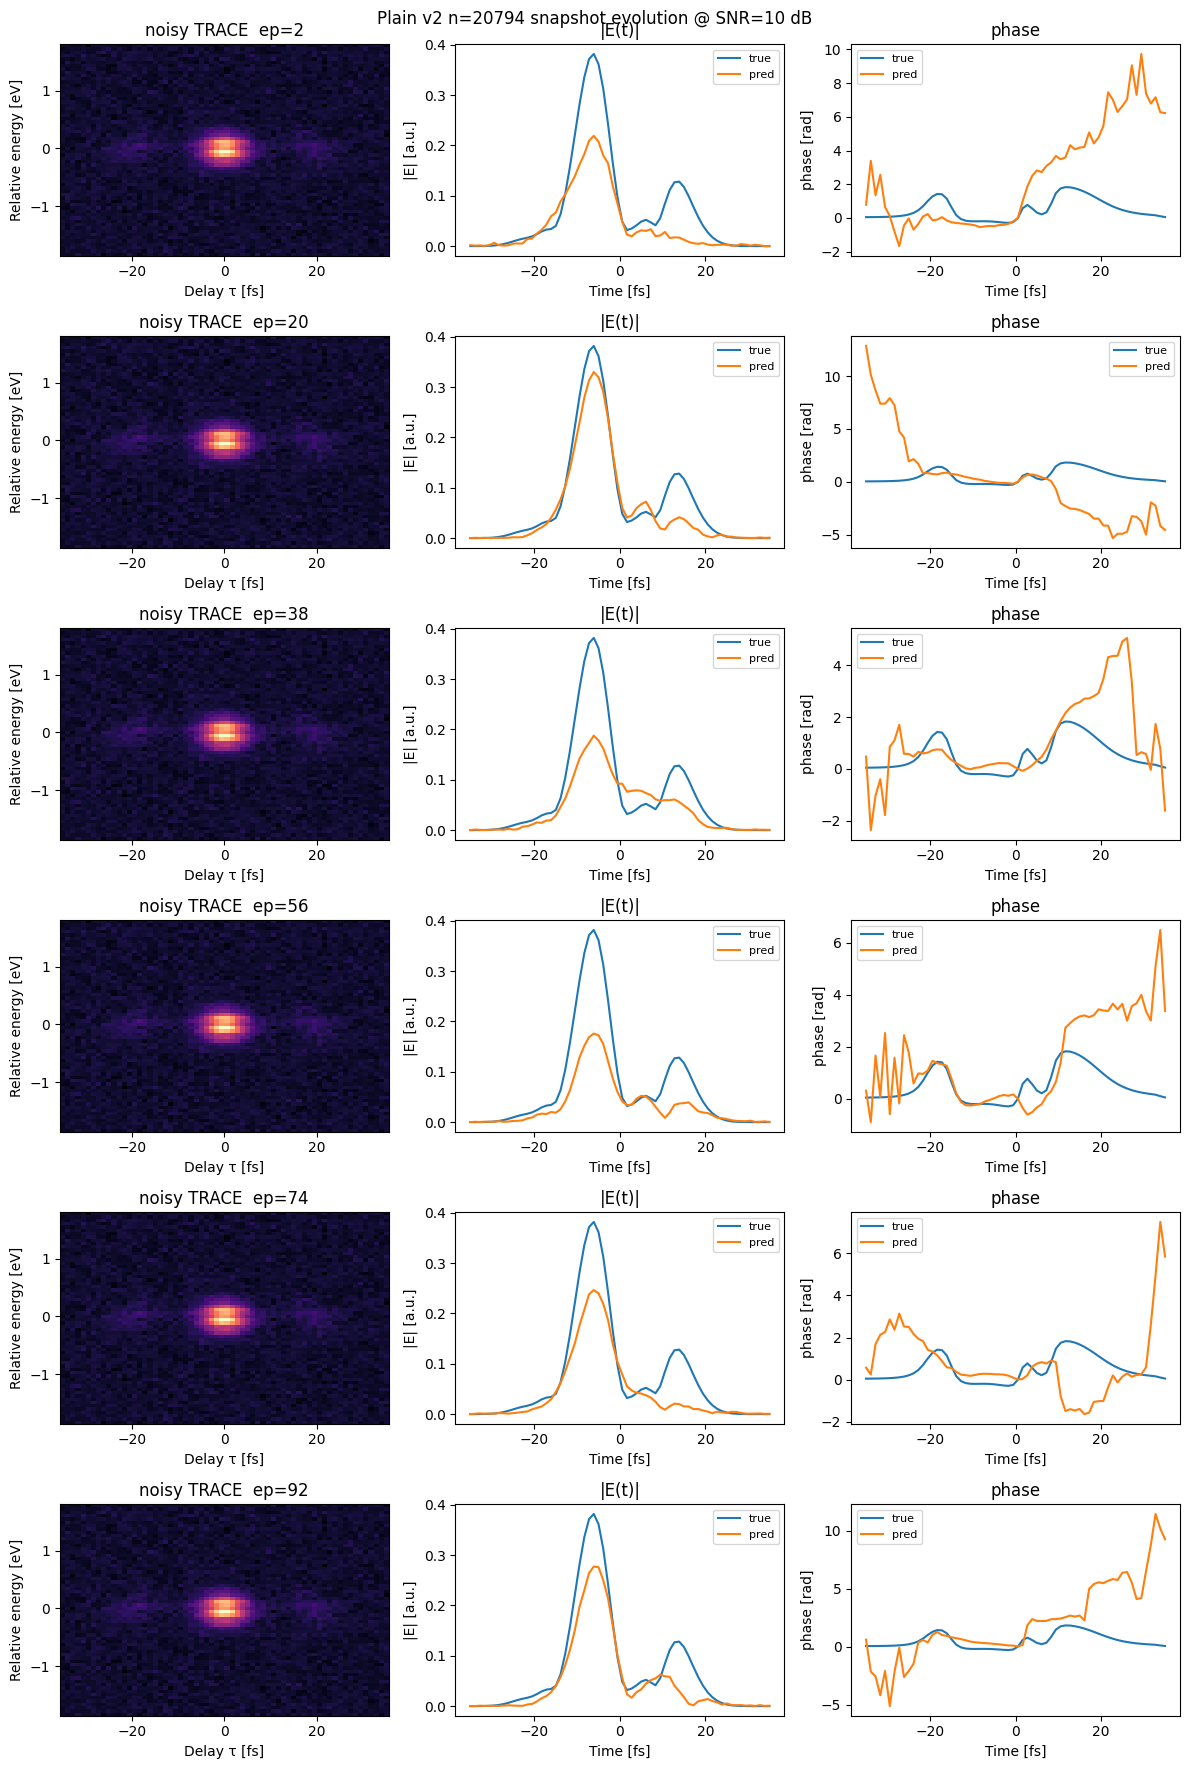

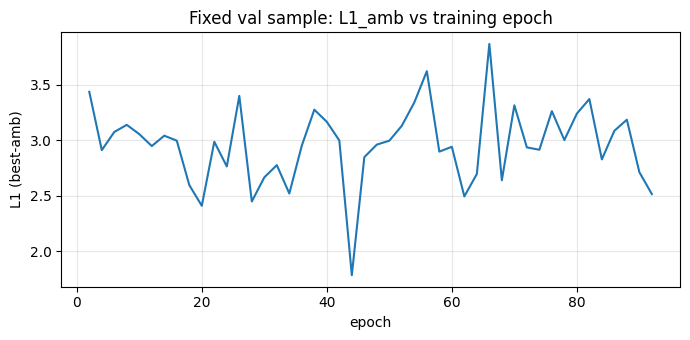

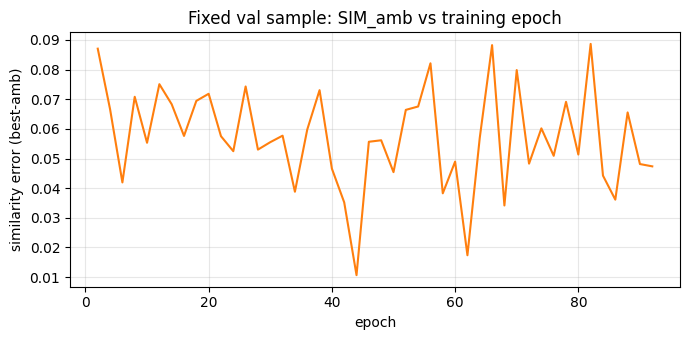

In [5]:
snap_path = OUT / f"{TAG}_snapshots.npz"
assert snap_path.exists(), snap_path
snap = np.load(snap_path)
epochs = snap["epoch"]
E_pred_all = snap["E_pred"]
if E_pred_all.ndim == 3:
    E_pred_all = E_pred_all[:, 0, :]
E_true = snap["E_true"]
if E_true.ndim == 3:
    E_true = E_true[0]
elif E_true.ndim == 2 and E_true.shape[0] == 1:
    E_true = E_true[0]
I_noisy = snap["I_noisy"]
if I_noisy.ndim == 4:
    I_noisy = I_noisy[0, 0]
elif I_noisy.ndim == 3:
    I_noisy = I_noisy[0]

pulse_cfg = filtered_c1_pulse_config(n=64)
dt = float(pulse_cfg.dt)
t_axis = np.linspace(-pulse_cfg.t_total_fs / 2.0, pulse_cfg.t_total_fs / 2.0, pulse_cfg.n)
e_true = unpack_packed_field(E_true)
I_show, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_noisy, num_points=pulse_cfg.n, dt=dt
)
energy_ev = omega_plot * 4.135667696 / (2.0 * np.pi)
extent = [tau_axis[0], tau_axis[-1], energy_ev[0], energy_ev[-1]]

n_show = min(6, len(epochs))
show_idx = np.unique(np.linspace(0, len(epochs) - 1, n_show, dtype=int)).tolist()
fig, axes = plt.subplots(len(show_idx), 3, figsize=(12, 3.0 * len(show_idx)))
if len(show_idx) == 1:
    axes = np.array([axes])
for row, si in enumerate(show_idx):
    e_pred = unpack_packed_field(E_pred_all[si])
    e_al = best_l1_ambiguity_field(e_pred, e_true)
    amp_p, amp_t = np.abs(e_al), np.abs(e_true)
    ph_t, ph_p = unwrap_phases_for_overlay(e_al, e_true)
    axes[row, 0].imshow(
        I_show, aspect="auto", origin="lower", extent=extent, cmap="magma"
    )
    axes[row, 0].set_title(f"noisy TRACE  ep={int(epochs[si])}")
    axes[row, 0].set_xlabel("Delay τ [fs]")
    axes[row, 0].set_ylabel("Relative energy [eV]")
    axes[row, 1].plot(t_axis, amp_t, label="true")
    axes[row, 1].plot(t_axis, amp_p, label="pred")
    axes[row, 1].set_title("|E(t)|")
    axes[row, 1].set_xlabel("Time [fs]")
    axes[row, 1].set_ylabel("|E| [a.u.]")
    axes[row, 1].legend(fontsize=8)
    axes[row, 2].plot(t_axis, ph_t, label="true")
    axes[row, 2].plot(t_axis, ph_p, label="pred")
    axes[row, 2].set_title("phase")
    axes[row, 2].set_xlabel("Time [fs]")
    axes[row, 2].set_ylabel("phase [rad]")
    axes[row, 2].legend(fontsize=8)
plt.suptitle(f"Plain v2 n={N_TRAIN} snapshot evolution @ SNR={SNAPSHOT_SNR_DB:g} dB")
plt.tight_layout()
plt.show()

l1s, sims = [], []
for i in range(len(epochs)):
    e_pred = unpack_packed_field(E_pred_all[i])
    l1s.append(best_l1_ambiguity(e_pred, e_true))
    sims.append(best_similarity_error_ambiguity(e_pred, e_true))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs, l1s, color="C0")
ax.set_xlabel("epoch")
ax.set_ylabel("L1 (best-amb)")
ax.set_title("Fixed val sample: L1_amb vs training epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs, sims, color="C1")
ax.set_xlabel("epoch")
ax.set_ylabel("similarity error (best-amb)")
ax.set_title("Fixed val sample: SIM_amb vs training epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Held-out test SNR sweep


skip sweep; using d:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n20794_plain\n20794_plain_lr1e-3_v2_test_snr_sweep.npz


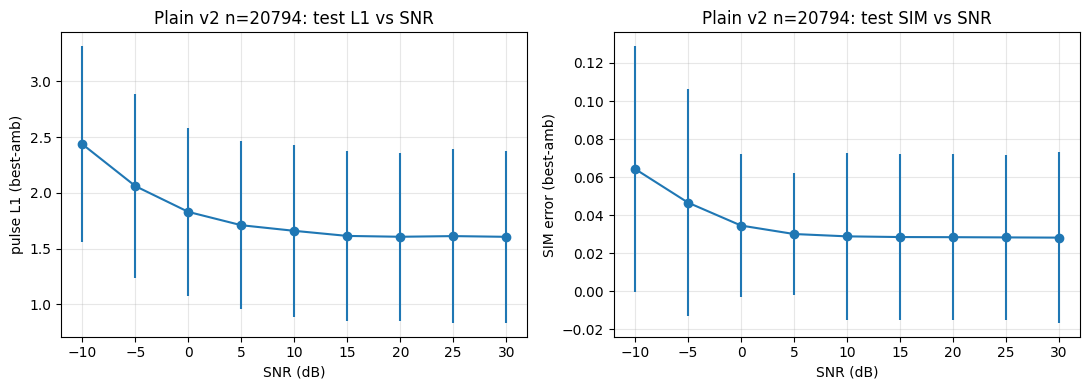

  SNR= -10.0  L1_amb=2.4354  SIM_amb=0.0642
  SNR=  -5.0  L1_amb=2.0601  SIM_amb=0.0465
  SNR=   0.0  L1_amb=1.8289  SIM_amb=0.0345
  SNR=   5.0  L1_amb=1.7094  SIM_amb=0.0300
  SNR=  10.0  L1_amb=1.6591  SIM_amb=0.0288
  SNR=  15.0  L1_amb=1.6134  SIM_amb=0.0284
  SNR=  20.0  L1_amb=1.6059  SIM_amb=0.0283
  SNR=  25.0  L1_amb=1.6118  SIM_amb=0.0282
  SNR=  30.0  L1_amb=1.6054  SIM_amb=0.0281


In [6]:
bundle = build_filtered_c1_frog_dataloaders(
    n_train=max(N_TRAIN, 64),
    n_val=N_VAL,
    n_test=N_TEST,
    batch_size=BATCH_SIZE,
    seed=SEED,
    device=DEVICE,
    grid=filtered_c1_pulse_config(n=64),
    canonicalize_mode="t0",
)
test_loader = bundle.test_loader

sweep_path = OUT / f"{TAG}_test_snr_sweep.npz"
if FORCE_TEST_SWEEP or not sweep_path.exists():
    print("Running test SNR sweep...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{TAG}_model.pt",
        sweep_path,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name=f"Plain v2 n={N_TRAIN} LR={LR:g}",
    )
else:
    print("skip sweep; using", sweep_path)

sweep = load_cnn_sweep(sweep_path)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(
    sweep.snr_sweep_db, sweep.cnn_l1_amb_m, yerr=sweep.cnn_l1_amb_s, marker="o"
)
axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("pulse L1 (best-amb)")
axes[0].set_title(f"Plain v2 n={N_TRAIN}: test L1 vs SNR")
axes[0].grid(True, alpha=0.3)
axes[1].errorbar(
    sweep.snr_sweep_db, sweep.cnn_sim_amb_m, yerr=sweep.cnn_sim_amb_s, marker="o"
)
axes[1].set_xlabel("SNR (dB)")
axes[1].set_ylabel("SIM error (best-amb)")
axes[1].set_title(f"Plain v2 n={N_TRAIN}: test SIM vs SNR")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
for snr, l1, sim in zip(sweep.snr_sweep_db, sweep.cnn_l1_amb_m, sweep.cnn_sim_amb_m):
    print(f"  SNR={snr:6.1f}  L1_amb={l1:.4f}  SIM_amb={sim:.4f}")


## Test example @ SNR = 10 dB


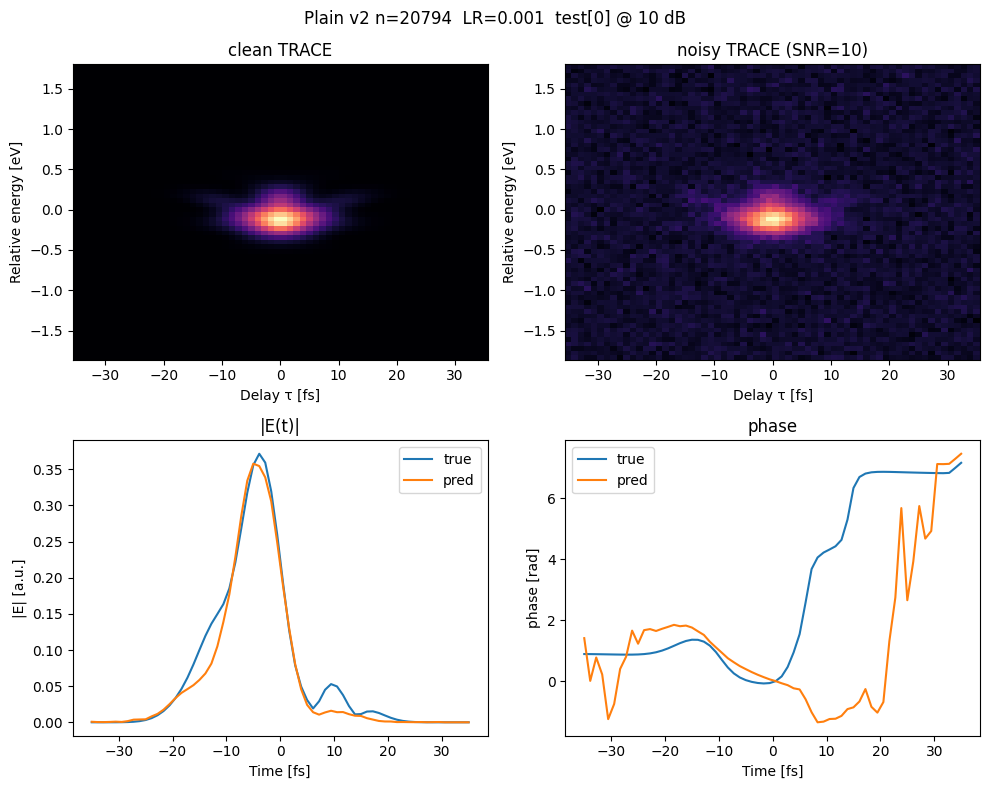

L1_amb: 1.4447638988494873
SIM_amb: 0.022548070823802613


In [7]:
model = diag.load_trained_multires(OUT / f"{TAG}_model.pt", device=DEVICE)
model.eval()

pulse_cfg = filtered_c1_pulse_config(n=64)
dt = float(pulse_cfg.dt)
t_axis = np.linspace(-pulse_cfg.t_total_fs / 2.0, pulse_cfg.t_total_fs / 2.0, pulse_cfg.n)

I_clean, E_true = test_loader.dataset[0]
I_clean_b = I_clean.unsqueeze(0).to(DEVICE)
E_np = E_true.detach().cpu().numpy()
g = torch.Generator()
g.manual_seed(999)
noise = torch.randn(I_clean_b.shape, generator=g, dtype=I_clean_b.dtype)
pwr = I_clean_b.pow(2).mean().clamp_min(1e-12)
sigma = torch.sqrt(pwr / (10.0 ** (10.0 / 10.0)))
I_noisy = I_clean_b + sigma * noise.to(DEVICE)

with torch.no_grad():
    E_pred = extract_pulse_prediction(model(I_noisy.unsqueeze(1))).squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_np)
e_pred = unpack_packed_field(E_pred)
e_al = best_l1_ambiguity_field(e_pred, e_true)
amp_p, amp_t = np.abs(e_al), np.abs(e_true)
ph_t, ph_p = unwrap_phases_for_overlay(e_al, e_true)
I_n, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_noisy.squeeze(0).cpu().numpy(),
    num_points=pulse_cfg.n,
    dt=dt,
)
I_c, _, _ = prepare_frog_trace_for_plot(
    I_clean_b.squeeze(0).cpu().numpy(),
    num_points=pulse_cfg.n,
    dt=dt,
)
energy_ev = omega_plot * 4.135667696 / (2.0 * np.pi)
extent = [tau_axis[0], tau_axis[-1], energy_ev[0], energy_ev[-1]]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(I_c, aspect="auto", origin="lower", extent=extent, cmap="magma")
axes[0, 0].set_title("clean TRACE")
axes[0, 0].set_xlabel("Delay τ [fs]")
axes[0, 0].set_ylabel("Relative energy [eV]")
axes[0, 1].imshow(I_n, aspect="auto", origin="lower", extent=extent, cmap="magma")
axes[0, 1].set_title("noisy TRACE (SNR=10)")
axes[0, 1].set_xlabel("Delay τ [fs]")
axes[0, 1].set_ylabel("Relative energy [eV]")
axes[1, 0].plot(t_axis, amp_t, label="true")
axes[1, 0].plot(t_axis, amp_p, label="pred")
axes[1, 0].set_title("|E(t)|")
axes[1, 0].set_xlabel("Time [fs]")
axes[1, 0].set_ylabel("|E| [a.u.]")
axes[1, 0].legend()
axes[1, 1].plot(t_axis, ph_t, label="true")
axes[1, 1].plot(t_axis, ph_p, label="pred")
axes[1, 1].set_title("phase")
axes[1, 1].set_xlabel("Time [fs]")
axes[1, 1].set_ylabel("phase [rad]")
axes[1, 1].legend()
plt.suptitle(f"Plain v2 n={N_TRAIN}  LR={LR:g}  test[0] @ 10 dB")
plt.tight_layout()
plt.show()

print("L1_amb:", best_l1_ambiguity(e_pred, e_true))
print("SIM_amb:", best_similarity_error_ambiguity(e_pred, e_true))


## Campaign summary row


In [8]:
summary = {
    "protocol": PROTOCOL,
    "n_train": N_TRAIN,
    "model": "plain",
    "lambda": 0.0,
    "LR": LR,
    "batch_size": BATCH_SIZE,
    "max_steps": MAX_STEPS,
    "patience_steps": PATIENCE_STEPS,
    "val_snr_values": VAL_SNR_VALUES,
    "best_epoch": meta["best_epoch"],
    "best_step": meta.get("best_step"),
    "best_score_val_amb": meta["best_score"],
    "stopped_epoch": meta["stopped_epoch"],
    "global_step": meta.get("global_step"),
    "wall_time_data_sec": meta.get("wall_time_data_sec"),
    "wall_time_train_sec": meta.get("wall_time_train_sec"),
    "device": meta.get("device"),
    "data": "filtered_c1",
    "tag": TAG,
    "snapshot_val_index": SNAPSHOT_VAL_INDEX,
    "snapshot_snr_db": SNAPSHOT_SNR_DB,
    "snapshot_noise_seed": SNAPSHOT_NOISE_SEED,
}
(OUT / "campaign_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
print(json.dumps(summary, indent=2))
print("wrote", OUT / "campaign_summary.json")


{
  "protocol": "v2",
  "n_train": 20794,
  "model": "plain",
  "lambda": 0.0,
  "LR": 0.001,
  "batch_size": 64,
  "max_steps": 187500,
  "patience_steps": 23437,
  "val_snr_values": [
    -10.0,
    0.0,
    30.0
  ],
  "best_epoch": 20,
  "best_step": 6500,
  "best_score_val_amb": 1.5830993518233298,
  "stopped_epoch": 93,
  "global_step": 30225,
  "wall_time_data_sec": 178.34238869999535,
  "wall_time_train_sec": 7824.5826544999145,
  "device": "cuda",
  "data": "filtered_c1",
  "tag": "n20794_plain_lr1e-3_v2",
  "snapshot_val_index": 0,
  "snapshot_snr_db": 10.0,
  "snapshot_noise_seed": 12345
}
wrote d:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n20794_plain\campaign_summary.json
